Telecommunication companies face significant revenue loss due to customer churn.

The objective of this project is:

1. Predict customer churn.
2. Identify factors causing churn.
3. Segment customers into meaningful groups.
4. Provide business recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(
    r"../data/raw_data/Telco_customer_churn.xlsx"
)

In [3]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [4]:
df.shape

(7043, 33)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [7]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [8]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

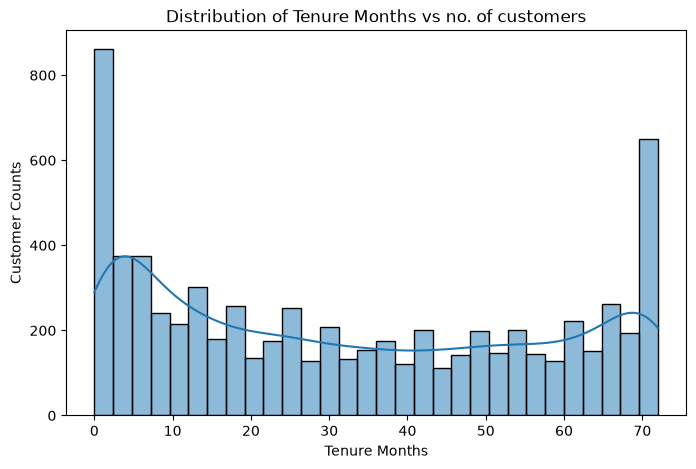

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'],bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Counts')
plt.title('Distribution of Tenure Months vs no. of customers')
plt.show()

In [11]:
df["Tenure Months"].max()

np.int64(72)

In [12]:
df["Tenure Months"].min()


np.int64(0)

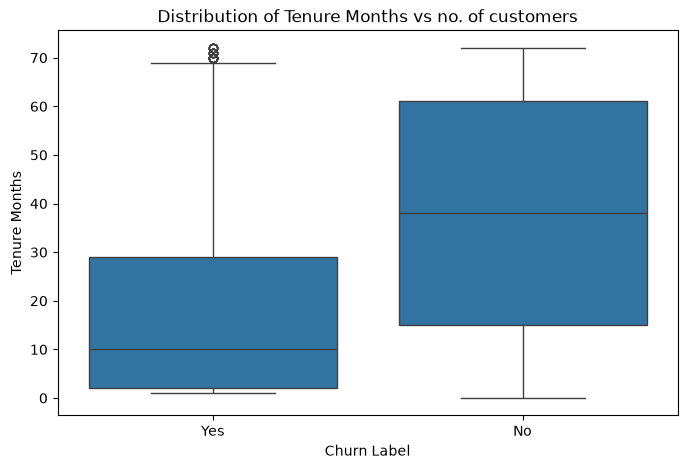

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, y='Tenure Months', x='Churn Label')
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Distribution of Tenure Months vs no. of customers')
plt.show()

In [14]:
df['Churn Label'].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [15]:
df['Churn Label']=='Yes'

0        True
1        True
2        True
3        True
4        True
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: Churn Label, Length: 7043, dtype: bool

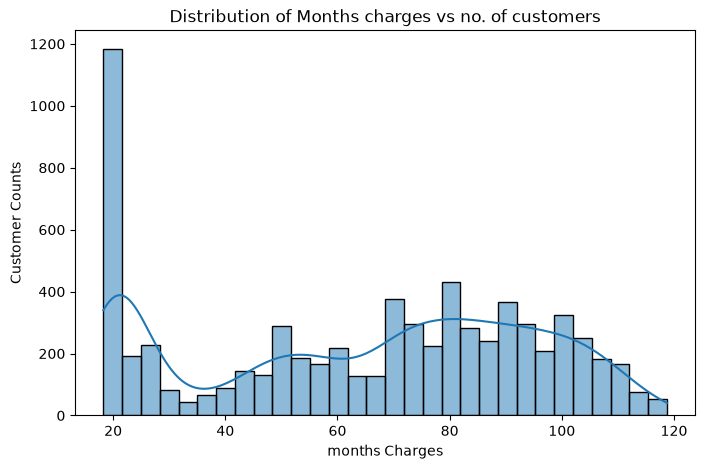

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'],bins=30, kde=True)
plt.xlabel('months Charges')
plt.ylabel('Customer Counts')
plt.title('Distribution of Months charges vs no. of customers')
plt.show()

In [17]:
df['Monthly Charges'].max()

np.float64(118.75)

In [18]:
df['Monthly Charges'].min()

np.float64(18.25)

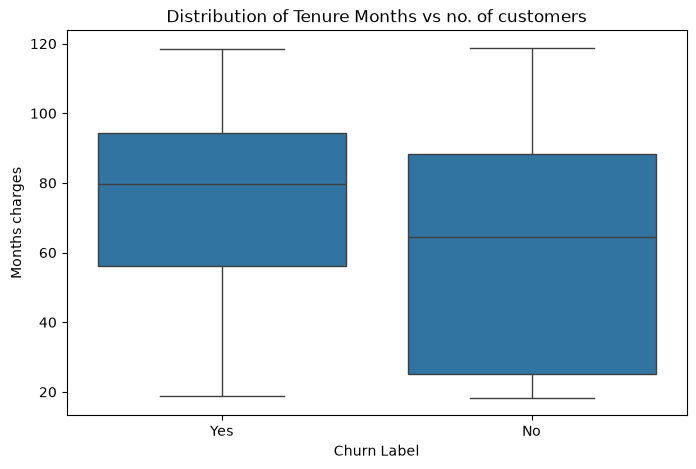

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, y='Monthly Charges', x='Churn Label')
plt.xlabel('Churn Label')
plt.ylabel('Months charges')
plt.title('Distribution of Tenure Months vs no. of customers')
plt.show()

In [20]:
df[df['Churn Label']=='Yes'
   ]['Monthly Charges'].quantile([0.25,0.5,0.75])

0.25    56.15
0.50    79.65
0.75    94.20
Name: Monthly Charges, dtype: float64

In [21]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

0.25    25.100
0.50    64.425
0.75    88.400
Name: Monthly Charges, dtype: float64

In [22]:
df['Monthly Charges'].describe()


count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charges, dtype: float64

In [23]:
df['Monthly Charges'].quantile([0.25,0.50,0.75])


0.25    35.50
0.50    70.35
0.75    89.85
Name: Monthly Charges, dtype: float64

In [24]:
df['Contract'].unique()

<ArrowStringArray>
['Month-to-month', 'Two year', 'One year']
Length: 3, dtype: str

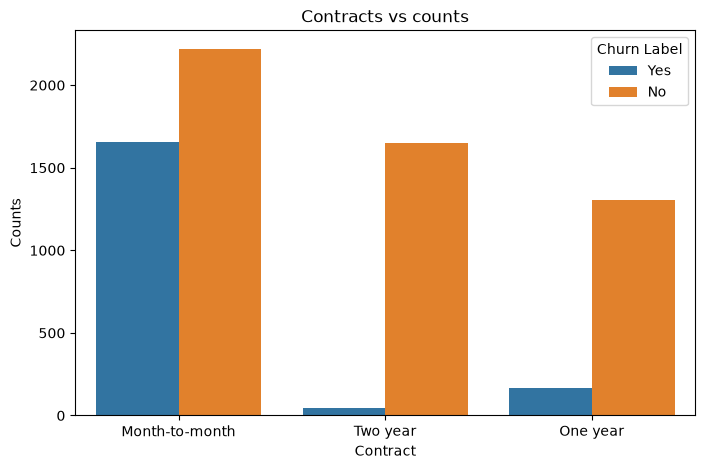

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn Label')
plt.xlabel('Contract')
plt.ylabel('Counts')
plt.title('Contracts vs counts')
plt.show()

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [27]:
df['Internet Service'].unique()

<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

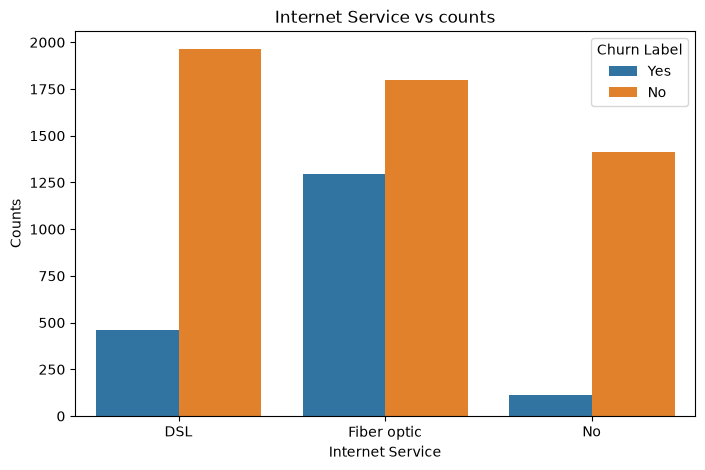

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Internet Service', hue='Churn Label')
plt.xlabel('Internet Service')
plt.ylabel('Counts')
plt.title('Internet Service vs counts')
plt.show()

In [29]:
df['Payment Method'].unique()

<ArrowStringArray>
[             'Mailed check',          'Electronic check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

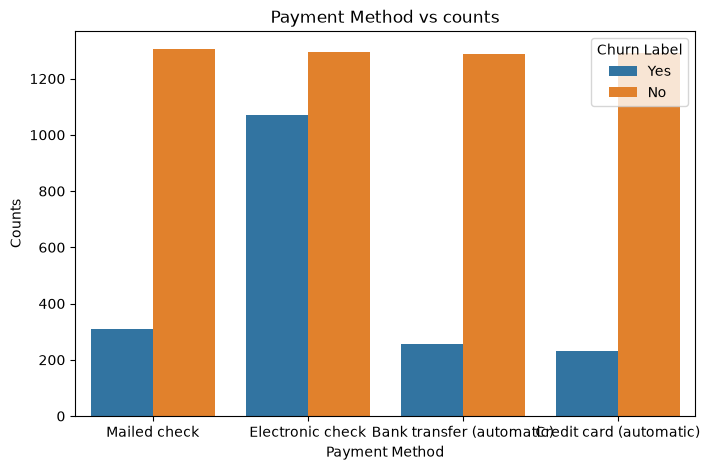

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Payment Method', hue='Churn Label')
plt.xlabel('Payment Method')
plt.ylabel('Counts')
plt.title('Payment Method vs counts')
plt.show()

In [31]:
df['Tech Support'].unique()

<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

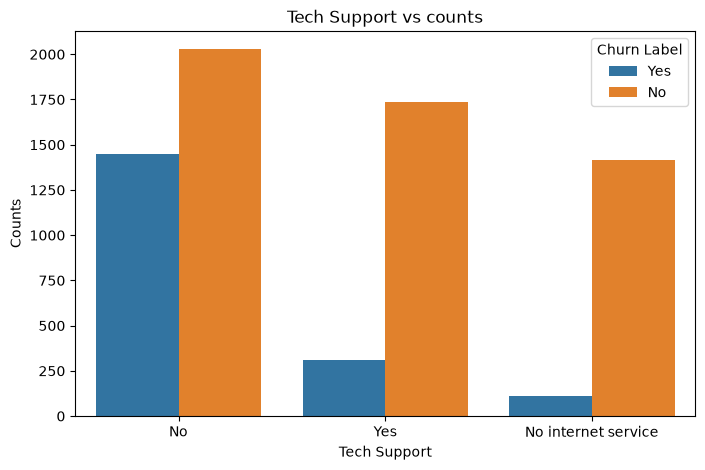

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Tech Support', hue='Churn Label')
plt.xlabel('Tech Support')
plt.ylabel('Counts')
plt.title('Tech Support vs counts')
plt.show()

In [33]:
avg_tenure = df.groupby('Churn Label')['Tenure Months'].mean()
avg_tenure

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [35]:
numerical_cols=['Tenure Months','Monthly Charges','Churn Score','CLTV']
correlation_matrix = df[numerical_cols].corr()

In [36]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.133754,0.098693
Churn Score,-0.224987,0.133754,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.079782,1.000000


In [37]:
contract_churn=pd.crosstab(df['Contract'],df['Churn Label'])
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [38]:
contract_churn=pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319
